# Comparación de Resultados de scikit-learn vs PySpark

In [3]:
from great_tables import GT, style, loc
import pandas as pd

df_comparacion = pd.DataFrame({
    "Métrica": ["AUC (ROC)", "Accuracy", "F1-score", "Recall", "Precision"],
    "scikit-learn": [0.6539, 0.6907, 0.4335, 0.5928, 0.3416],
    "PySpark":      [0.7676, 0.8117, 0.7432, 0.8117, 0.8129]
})

(GT(df_comparacion)
    .tab_header(title="Comparación de métricas", subtitle="scikit-learn vs PySpark")
    .fmt_number(columns=["scikit-learn", "PySpark"], decimals=4)
    .tab_style(
        style=style.fill(color="#d4edda"),
        locations=loc.body(columns="PySpark")
    )
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
)

GT(_tbl_data=     Métrica  scikit-learn  PySpark
0  AUC (ROC)        0.6539   0.7676
1   Accuracy        0.6907   0.8117
2   F1-score        0.4335   0.7432
3     Recall        0.5928   0.8117
4  Precision        0.3416   0.8129, _body=<great_tables._gt_data.Body object at 0x1257de0d0>, _boxhead=Boxhead([ColInfo(var='Métrica', type=<ColInfoTypeEnum.default: 1>, column_label='Métrica', column_align='left', column_width=None), ColInfo(var='scikit-learn', type=<ColInfoTypeEnum.default: 1>, column_label='scikit-learn', column_align='right', column_width=None), ColInfo(var='PySpark', type=<ColInfoTypeEnum.default: 1>, column_label='PySpark', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x120787750>, _spanners=Spanners([]), _heading=Heading(title='Comparación de métricas', subtitle='scikit-learn vs PySpark', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1257dd9d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1257de150>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='PySpark', rows=None, mask=None), grpname=None, colname='PySpark', rownum=0, colnum=None, styles=[CellStyleFill(color='#d4edda')]), StyleInfo(locname=LocBody(columns='PySpark', rows=None, mask=None), grpname=None, colname='PySpark', rownum=1, colnum=None, styles=[CellStyleFill(color='#d4edda')]), StyleInfo(locname=LocBody(columns='PySpark', rows=None, mask=None), grpname=None, colname='PySpark', rownum=2, colnum=None, styles=[CellStyleFill(color='#d4edda')]), StyleInfo(locname=LocBody(columns='PySpark', rows=None, mask=None), grpname=None, colname='PySpark', rownum=3, colnum=None, styles=[CellStyleFill(color='#d4edda')]), StyleInfo(locname=LocBody(columns='PySpark', rows=None, mask=None), grpname=None, colname='PySpark', rownum=4, colnum=None, styles=[CellStyleFill(color='#d4edda')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Métrica', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='scikit-learn', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='PySpark', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1257dcb90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1257de590>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, cat

PySpark superó a scikit-learn en todas las métricas evaluadas. El AUC pasó de 0.6539 a 0.7676 y el F1-score de 0.43 a 0.74 siendo esta última la diferencia más notable. Esto se explica principalmente porque scikit-learn usó class_weight='balanced' que sacrifica accuracy general para detectar más defaults mientras que PySpark entrenó sin ese ajuste favoreciendo la clase mayoritaria.

In [4]:
df_tiempos = pd.DataFrame({
    "Etapa": ["Entrenamiento (Grid Search)", "Predicción en test"],
    "scikit-learn (s)": [1030.47, 5.67],
    "PySpark (s)":      [565.51, 1.17]
})

(GT(df_tiempos)
    .tab_header(title="Tiempos de cómputo", subtitle="scikit-learn vs PySpark")
    .fmt_number(columns=["scikit-learn (s)", "PySpark (s)"], decimals=2)
    .tab_style(
        style=style.fill(color="#d4edda"),
        locations=loc.body(columns="PySpark (s)")
    )
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
)

GT(_tbl_data=                         Etapa  scikit-learn (s)  PySpark (s)
0  Entrenamiento (Grid Search)           1030.47       565.51
1           Predicción en test              5.67         1.17, _body=<great_tables._gt_data.Body object at 0x1079d6950>, _boxhead=Boxhead([ColInfo(var='Etapa', type=<ColInfoTypeEnum.default: 1>, column_label='Etapa', column_align='left', column_width=None), ColInfo(var='scikit-learn (s)', type=<ColInfoTypeEnum.default: 1>, column_label='scikit-learn (s)', column_align='right', column_width=None), ColInfo(var='PySpark (s)', type=<ColInfoTypeEnum.default: 1>, column_label='PySpark (s)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x107416b50>, _spanners=Spanners([]), _heading=Heading(title='Tiempos de cómputo', subtitle='scikit-learn vs PySpark', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x106e42490>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x10741fbd0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='PySpark (s)', rows=None, mask=None), grpname=None, colname='PySpark (s)', rownum=0, colnum=None, styles=[CellStyleFill(color='#d4edda')]), StyleInfo(locname=LocBody(columns='PySpark (s)', rows=None, mask=None), grpname=None, colname='PySpark (s)', rownum=1, colnum=None, styles=[CellStyleFill(color='#d4edda')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Etapa', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='scikit-learn (s)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='PySpark (s)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1218ee190>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1257ddc50>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', valu

En cuanto a tiempos PySpark fue significativamente más eficiente completando el grid search en 565 segundos frente a los 1030 de scikit-learn — casi el doble de rápido. La predicción también fue más veloz con 1.17 segundos vs 5.67 de scikit-learn sobre el mismo conjunto de prueba lo que confirma la ventaja de PySpark para procesar grandes volúmenes de datos.

### Visualización comparativa

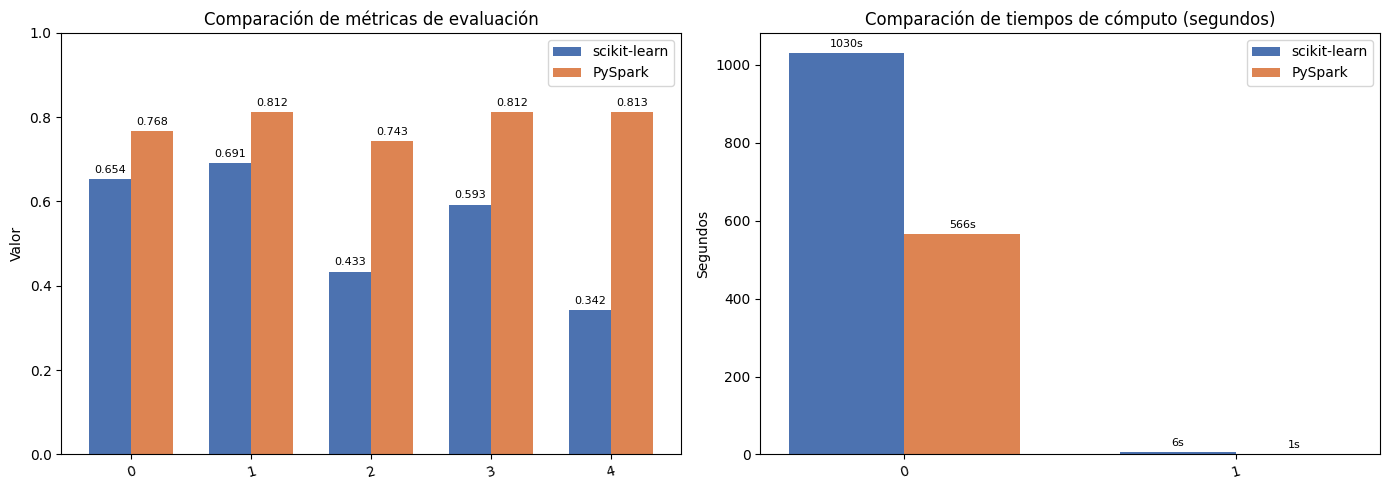

In [7]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas = df_comparacion.index.tolist()
x = np.arange(len(metricas))
width = 0.35

bars1 = axes[0].bar(x - width/2, df_comparacion["scikit-learn"], width, label="scikit-learn", color="#4C72B0")
bars2 = axes[0].bar(x + width/2, df_comparacion["PySpark"], width, label="PySpark", color="#DD8452")

axes[0].set_title("Comparación de métricas de evaluación")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].set_ylabel("Valor")

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

etapas = df_tiempos.index.tolist()
x2 = np.arange(len(etapas))

bars3 = axes[1].bar(x2 - width/2, df_tiempos["scikit-learn (s)"], width, label="scikit-learn", color="#4C72B0")
bars4 = axes[1].bar(x2 + width/2, df_tiempos["PySpark (s)"], width, label="PySpark", color="#DD8452")

axes[1].set_title("Comparación de tiempos de cómputo (segundos)")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(etapas, rotation=15)
axes[1].legend()
axes[1].set_ylabel("Segundos")

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{bar.get_height():.0f}s", ha="center", va="bottom", fontsize=8)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{bar.get_height():.0f}s", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Reflexión crítica

**¿Qué entorno fue más rápido?**

PySpark fue casi el doble de rápido en el grid search (565s vs 1030s) a pesar de que scikit-learn usó paralelismo con n_jobs=-1. Esto se debe a que PySpark distribuye el trabajo a nivel de particiones RDD aprovechando mejor los recursos del sistema. Para predicción PySpark también fue más rápido (1.17s vs 5.67s) sobre 268k filas lo que muestra su ventaja para inferencia a escala.

**¿Cuál fue más preciso?**

PySpark obtuvo mejores métricas en todas las categorías con AUC de 0.7676 vs 0.6539 de scikit-learn y F1 de 0.74 vs 0.43. Sin embargo esta diferencia puede explicarse parcialmente porque scikit-learn usó class_weight='balanced' para compensar el desbalance de clases lo que afectó sus métricas de accuracy pero mejoró el recall de la clase minoritaria. También hubo diferencias en el preprocesamiento y las variables usadas en cada entorno.

**¿Cuándo es útil PySpark?**

PySpark es útil cuando el dataset no cabe en la memoria de una sola máquina o cuando se necesita escalar el procesamiento a múltiples nodos. En este proyecto con 1.3M filas ya se notaron las ventajas en velocidad de entrenamiento y predicción. Para datasets más pequeños scikit-learn es más simple de implementar y suficiente.

**¿Qué aporta LIME?**

LIME permite entender por qué el modelo tomó una decisión específica en un caso individual. En un contexto financiero esto es crítico porque un banco no puede rechazar un préstamo sin poder explicar la razón. LIME convierte el modelo de caja negra en algo interpretable localmente mostrando qué variables empujaron la predicción hacia default o hacia pago en cada caso concreto. En este proyecto variables como bc_util, fico_range_high y mo_sin_old_rev_tl_op fueron las más influyentes en las predicciones individuales.

### Conclusión general

El preprocesamiento con scikit-learn permitió reducir el dataset de 151 a 70 columnas eliminando variables que producen data leakage variables basura y con alto porcentaje de NA. Se aplicó una estrategia diferenciada de encoding dividiendo las variables en ordinales nominales y de alta cardinalidad usando OrdinalEncoder OneHotEncoder y Frequency Encoding respectivamente llevando el dataset a 94 columnas finales.

El RandomForestClassifier con GridSearchCV obtuvo un ROC AUC de 0.6539 en test con un Recall de 59.28% y tras seleccionar las 25 variables más importantes mediante Feature Importance el Recall mejoró a 67.32% manteniendo el ROC AUC prácticamente igual en 0.6541. El análisis con LIME permitió identificar que variables como `bc_util`, `fico_range_high` y `mo_sin_old_rev_tl_op` fueron las más influyentes en las predicciones individuales del modelo.

En PySpark se replicó el mismo enfoque de modelado con RandomForestClassifier obteniendo un AUC de 0.7676 y completando el grid search en la mitad del tiempo que scikit-learn gracias al procesamiento distribuido. En general el modelo muestra un desempeño moderado con capacidad para detectar aproximadamente 7 de cada 10 defaults reales lo cual es un resultado aceptable considerando el desbalance de clases del dataset y la complejidad inherente de predecir incumplimientos financieros.